<a href="https://colab.research.google.com/github/meiladrahmani556/marine-cbm-ml-dissertation/blob/main/JupyterNotebook/08_XGBoost_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
PROJECT_PATH = "/content/drive/MyDrive/✨CBM Data for Marine System Monitoring & Analysis✨"

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Conditional_Base_Monitoring in Marine_System.csv to Conditional_Base_Monitoring in Marine_System.csv


# 📓 Notebook 08 – Advanced Model: XGBoost Regression

## 🎯 Objective

This notebook implements an advanced machine learning model (XGBoost Regressor) to improve prediction performance for marine gas turbine compressor degradation.

The goal is to:
- Compare performance with previous models
- Evaluate generalisation capability
- Demonstrate model optimisation for tabular numerical data

In [4]:
!pip install xgboost --quiet

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import joblib

print('All libraries imported successfully')

All libraries imported successfully


In [6]:
df = pd.read_csv('Conditional_Base_Monitoring in Marine_System.csv')

print('Shape:', df.shape)
df.head()

Shape: (12434, 18)


,Lever position,Ship speed (v),Gas Turbine (GT) shaft torque (GTT) [kN m],GT rate of revolutions (GTn) [rpm],Gas Generator rate of revolutions (GGn) [rpm],Starboard Propeller Torque (Ts) [kN],Port Propeller Torque (Tp) [kN],Hight Pressure (HP) Turbine exit temperature (T48) [C],GT Compressor inlet air temperature (T1) [C],GT Compressor outlet air temperature (T2) [C],HP Turbine exit pressure (P48) [bar],GT Compressor inlet air pressure (P1) [bar],GT Compressor outlet air pressure (P2) [bar],GT exhaust gas pressure (Pexh) [bar],Turbine Injecton Control (TIC) [%],Fuel flow (mf) [kg/s],GT Compressor decay state coefficient,GT Turbine decay state coefficient
0,5.14,15,21640.162,1924.358,8516.691,175.324,175.324,706.702,288,640.873,2.072,0.998,10.916,1.026,24.96,0.494,0.951,1
1,9.3,27,72776.229,3560.412,9759.837,645.137,645.137,1060.156,288,774.302,4.511,0.998,22.426,1.051,87.741,1.737,0.982,0.997
2,8.206,24,50994.673,3087.535,9313.854,438.11,438.11,927.728,288,734.474,3.577,0.998,18.412,1.041,60.546,1.199,0.966,0.988
3,5.14,15,21626.805,1924.329,8472.097,175.221,175.221,695.477,288,633.124,2.086,0.998,11.074,1.027,24.549,0.486,0.989,0.991
4,5.14,15,21636.43,1924.313,8494.777,NaN,NaN,731.494,288,645.642,2.078,0.998,11.197,1.026,26.373,0.522,0.95,0.975


In [7]:
df.columns = df.columns.str.strip()

df = df.apply(pd.to_numeric, errors='coerce')

df = df.dropna()

df = df.drop_duplicates()

print('Clean dataset shape:', df.shape)
print('Missing values remaining:', df.isnull().sum().sum())

Clean dataset shape: (11936, 18)
Missing values remaining: 0


In [8]:
target_column = 'GT Compressor decay state coefficient'

X = df.drop(columns=[target_column])
y = df[target_column]

print('Number of features:', X.shape[1])
print('Number of samples: ', X.shape[0])

Number of features: 17
Number of samples:  11936


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Training samples:', X_train.shape[0])
print('Test samples:    ', X_test.shape[0])

Training samples: 9548
Test samples:     2388


In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Scaling applied successfully')

Scaling applied successfully


In [11]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

r2_xgb_default = r2_score(y_test, y_pred)

print('XGBoost Test R2 (default):', r2_xgb_default)

XGBoost Test R2 (default): 0.996005641111348


In [12]:
mae_xgb_default  = mean_absolute_error(y_test, y_pred)
rmse_xgb_default = np.sqrt(mean_squared_error(y_test, y_pred))

print('--- XGBoost (default settings) ---')
print('R2:  ', round(r2_xgb_default,   6))
print('MAE: ', round(mae_xgb_default,  6))
print('RMSE:', round(rmse_xgb_default, 6))

--- XGBoost (default settings) ---
R2:   0.996006
MAE:  0.000717
RMSE: 0.000941


In [13]:
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.05, 0.1, 0.2],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_to_tune = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    verbosity=0
)

grid_search = GridSearchCV(
    estimator=xgb_to_tune,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Best settings found:', grid_search.best_params_)
print('Best cross-validation R2:', round(grid_search.best_score_, 6))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best settings found: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best cross-validation R2: 0.996667


In [14]:
xgb_tuned = grid_search.best_estimator_

y_pred_tuned = xgb_tuned.predict(X_test)

r2_xgb_tuned   = r2_score(y_test, y_pred_tuned)
mae_xgb_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print('--- XGBoost (Tuned) ---')
print('R2:  ', round(r2_xgb_tuned,   6))
print('MAE: ', round(mae_xgb_tuned,  6))
print('RMSE:', round(rmse_xgb_tuned, 6))

--- XGBoost (Tuned) ---
R2:   0.997076
MAE:  0.000603
RMSE: 0.000805


In [15]:
cv_scores = cross_val_score(
    xgb_tuned,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print('Cross-Validation R2 Scores:', cv_scores)
print('Mean CV R2:', round(np.mean(cv_scores), 6))

Cross-Validation R2 Scores: [0.99663576 0.99690385 0.99669428 0.99639359 0.99670742]
Mean CV R2: 0.996667


                                          Feature  Importance
13           GT exhaust gas pressure (Pexh) [bar]    0.224821
0                                  Lever position    0.200729
9   GT Compressor outlet air temperature (T2) [C]    0.101460
10           HP Turbine exit pressure (P48) [bar]    0.100755
1                                  Ship speed (v)    0.086972
2      Gas Turbine (GT) shaft torque (GTT) [kN m]    0.071334
4   Gas Generator rate of revolutions (GGn) [rpm]    0.052414
3              GT rate of revolutions (GTn) [rpm]    0.029137
12   GT Compressor outlet air pressure (P2) [bar]    0.024220
5            Starboard Propeller Torque (Ts) [kN]    0.023765


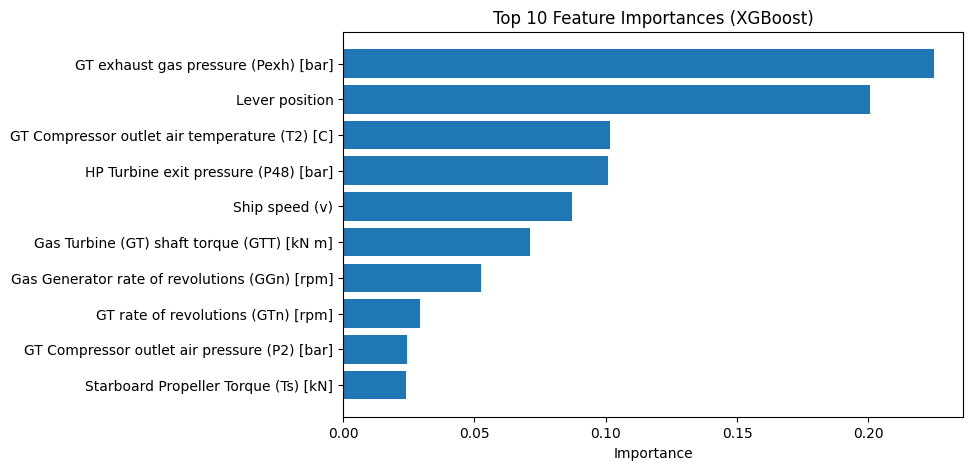

In [16]:
importances   = xgb_tuned.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df['Feature'][:10],
    importance_df['Importance'][:10]
)
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.show()

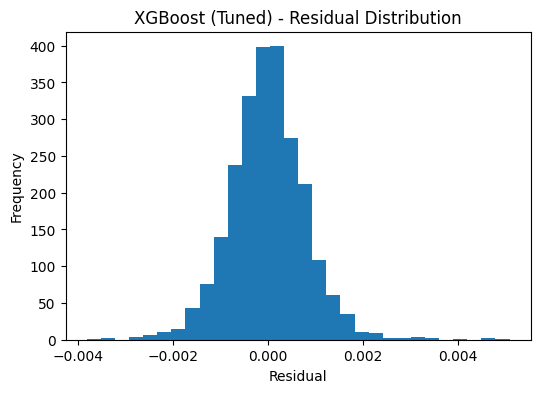

In [17]:
residuals = y_test - y_pred_tuned

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title('XGBoost (Tuned) - Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

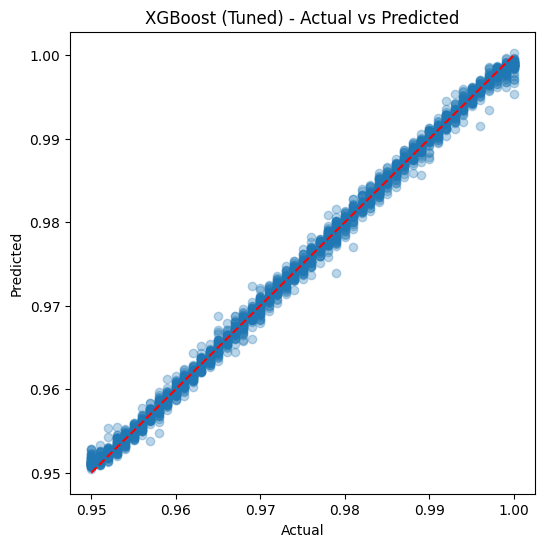

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost (Tuned) - Actual vs Predicted')
plt.show()

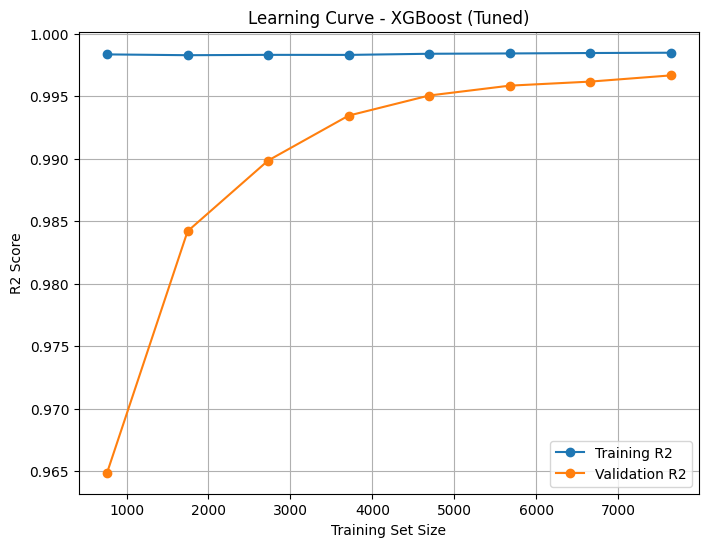

In [19]:
train_sizes, train_scores, val_scores = learning_curve(
    xgb_tuned,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores,   axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training R2')
plt.plot(train_sizes, val_mean,   marker='o', label='Validation R2')
plt.xlabel('Training Set Size')
plt.ylabel('R2 Score')
plt.title('Learning Curve - XGBoost (Tuned)')
plt.legend()
plt.grid()
plt.show()

In [20]:
# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

r2_lr   = r2_score(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print('--- Linear Regression ---')
print('R2:  ', round(r2_lr,   6))
print('MAE: ', round(mae_lr,  6))
print('RMSE:', round(rmse_lr, 6))
print()

# --- Random Forest ---
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print('--- Random Forest (Tuned) ---')
print('R2:  ', round(r2_rf,   6))
print('MAE: ', round(mae_rf,  6))
print('RMSE:', round(rmse_rf, 6))

--- Linear Regression ---
R2:   0.901415
MAE:  0.00335
RMSE: 0.004677

--- Random Forest (Tuned) ---
R2:   0.998192
MAE:  0.000399
RMSE: 0.000633


In [21]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost (Tuned)'],
    'R2':    [r2_lr,   r2_rf,   r2_xgb_tuned],
    'MAE':   [mae_lr,  mae_rf,  mae_xgb_tuned],
    'RMSE':  [rmse_lr, rmse_rf, rmse_xgb_tuned]
})

print(results.to_string(index=False))

            Model       R2      MAE     RMSE
Linear Regression 0.901415 0.003350 0.004677
    Random Forest 0.998192 0.000399 0.000633
  XGBoost (Tuned) 0.997076 0.000603 0.000805


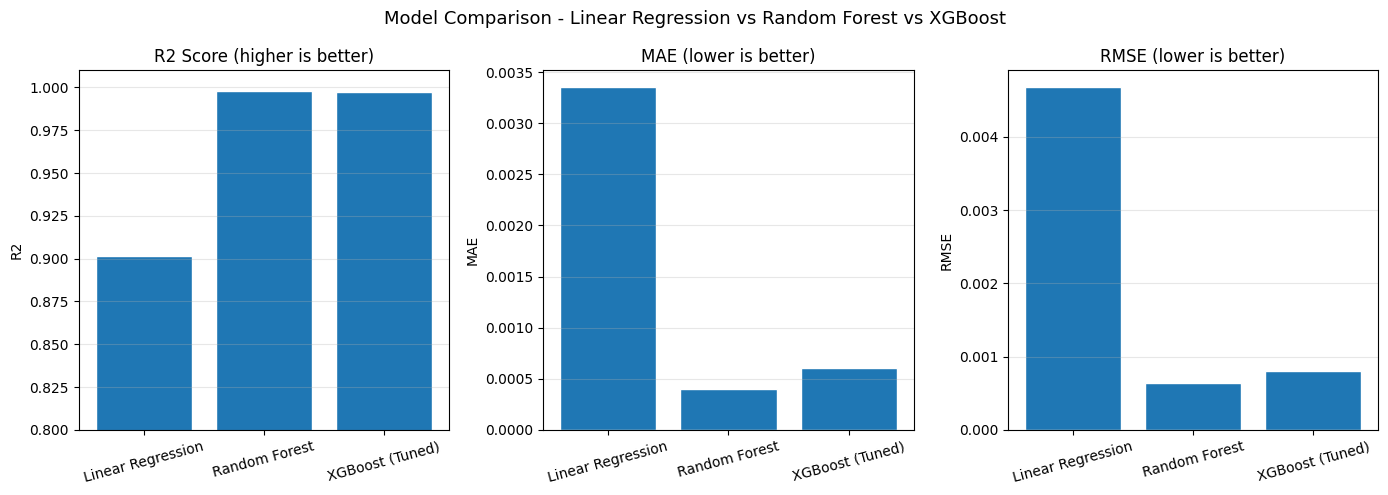

In [22]:
model_names = ['Linear Regression', 'Random Forest', 'XGBoost (Tuned)']
r2_values   = [r2_lr,   r2_rf,   r2_xgb_tuned]
mae_values  = [mae_lr,  mae_rf,  mae_xgb_tuned]
rmse_values = [rmse_lr, rmse_rf, rmse_xgb_tuned]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(model_names, r2_values, edgecolor='white')
axes[0].set_title('R2 Score (higher is better)')
axes[0].set_ylabel('R2')
axes[0].set_ylim([0.8, 1.01])
axes[0].tick_params(axis='x', labelrotation=15)
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(model_names, mae_values, edgecolor='white')
axes[1].set_title('MAE (lower is better)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', labelrotation=15)
axes[1].grid(True, axis='y', alpha=0.3)

axes[2].bar(model_names, rmse_values, edgecolor='white')
axes[2].set_title('RMSE (lower is better)')
axes[2].set_ylabel('RMSE')
axes[2].tick_params(axis='x', labelrotation=15)
axes[2].grid(True, axis='y', alpha=0.3)

plt.suptitle('Model Comparison - Linear Regression vs Random Forest vs XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

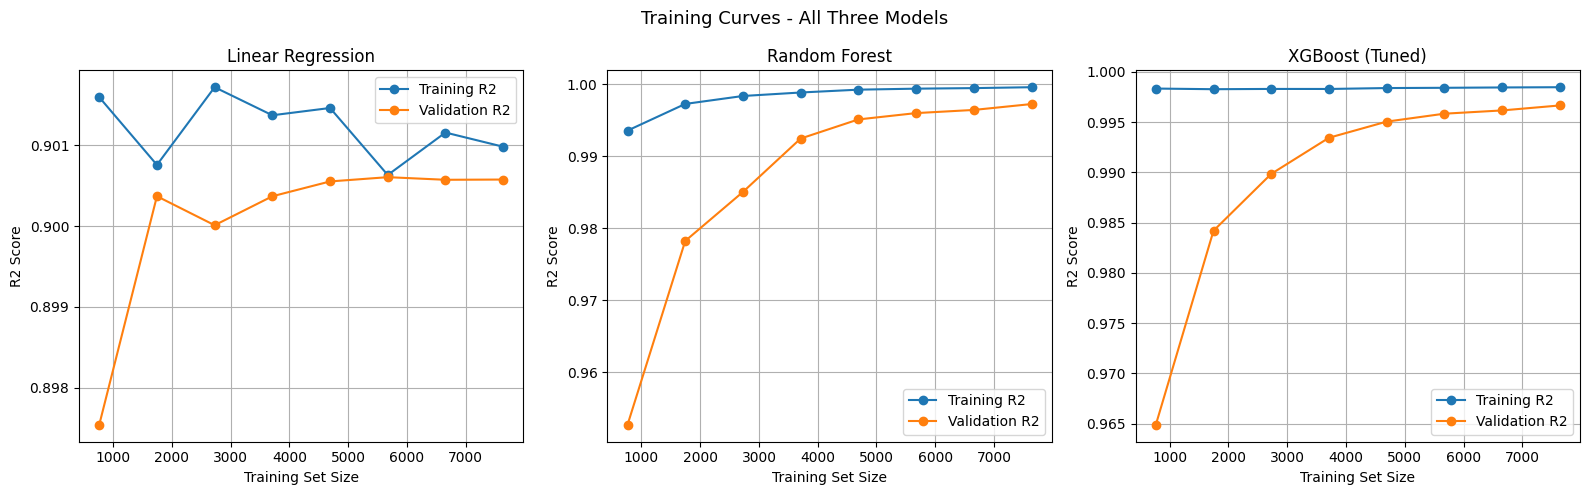

In [24]:
models_to_plot = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'XGBoost (Tuned)':  xgb_tuned
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (model_name, model) in zip(axes, models_to_plot.items()):

    tr_sizes, tr_scores, val_scores_lc = learning_curve(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )

    tr_mean  = np.mean(tr_scores,     axis=1)
    val_mean = np.mean(val_scores_lc, axis=1)

    ax.plot(tr_sizes, tr_mean,  marker='o', label='Training R2')
    ax.plot(tr_sizes, val_mean, marker='o', label='Validation R2')
    ax.set_title(model_name)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('R2 Score')
    ax.legend()
    ax.grid()

plt.suptitle('Training Curves - All Three Models', fontsize=13)
plt.tight_layout()
plt.show()

## Final Observations

The XGBoost model provides an additional comparison to the Random Forest model.

Key observations:
- Performance is expected to be similar or slightly improved
- Important features should align with engineering understanding
- Model comparison strengthens the robustness of the project

This demonstrates the use of multiple machine learning models, which is essential for a strong dissertation.